In [16]:
# Core libraries
import pandas as pd
import numpy as np

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Save models
import joblib


In [17]:
df2=pd.read_csv('career_ready_dataset_final.csv')

In [18]:
df2.shape

(1195, 7)

In [19]:
df2.head()

,course,specialization,interests,skills,combined,course_spec,career
0,b.sc,computer applications,cloud computing,python;sql;java,b.sc computer applications cloud computing pyt...,b.sc computer applications,web developer
1,b.e,computer science engineering,technology,"critical thinking, analytic thinking, sql, pro...",b.e computer science engineering technology cr...,b.e computer science engineering,software engineer
2,ba,psychology,understand human behaviour,people management;communication skills,ba psychology understand human behaviour peopl...,ba psychology,psychologist
3,mba,commerce,sales/marketing;trading;understand human behav...,accounting skills;critical thinking,mba commerce sales/marketing;trading;understan...,mba commerce,accountant
4,b.tech,instrumentation engineering,technology,plc allen bradley;plc ladder logic;labview;bus...,b.tech instrumentation engineering technology ...,b.tech instrumentation engineering,automation engineer


In [20]:
print("Columns:", df2.columns.tolist())
print("\nMissing values per column:\n", df2.isnull().sum())

# Fill NaN with empty strings (for text columns)
df2 = df2.fillna('')


Columns: ['course', 'specialization', 'interests', 'skills', 'combined', 'course_spec', 'career']

Missing values per column:
 course            0
specialization    0
interests         0
skills            1
combined          0
course_spec       0
career            0
dtype: int64


In [ ]:
# Remove classes that have fewer than 2 samples
counts = df2['career'].value_counts()
rare_classes = counts[counts < 2].index
print("Rare classes being dropped:", list(rare_classes))

df2 = df2[~df2['career'].isin(rare_classes)].reset_index(drop=True)


Rare classes being dropped: ['business manager']


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\n✅ Data split successful!")
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


✅ Data split successful!
Train samples: 955
Test samples: 239


In [28]:
#Step 9️⃣ — TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    stop_words='english',
    max_features=2000,
    ngram_range=(1,2)
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [29]:
print("\n📈 TF-IDF Vectorization complete!")
print("Train shape:", X_train_tfidf.shape, " Test shape:", X_test_tfidf.shape)



📈 TF-IDF Vectorization complete!
Train shape: (955, 2000)  Test shape: (239, 2000)


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=300,     # number of trees
    max_depth=None,       # full tree depth
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)



In [31]:
# Train the model
rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [32]:
#Predictions
y_pred_rf = rf_model.predict(X_test_tfidf)

In [33]:
# Step 1️⃣1️⃣ — Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf_weighted = f1_score(y_test, y_pred_rf, average='weighted')
f1_rf_macro = f1_score(y_test, y_pred_rf, average='macro')


In [34]:
print("\n🌲 RANDOM FOREST PERFORMANCE:")
print(f"Accuracy: {acc_rf*100:.2f}%")
print(f"Weighted F1: {f1_rf_weighted:.4f}")
print(f"Macro F1: {f1_rf_macro:.4f}")


🌲 RANDOM FOREST PERFORMANCE:
Accuracy: 82.43%
Weighted F1: 0.7913
Macro F1: 0.4289


In [35]:
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))



📋 Classification Report:
                                        precision    recall  f1-score   support

                            accountant       1.00      0.94      0.97        17
                  agricultural officer       0.00      0.00      0.00         1
                   automobile engineer       1.00      1.00      1.00        10
                             biologist       0.00      0.00      0.00         2
                    biotech researcher       0.00      0.00      0.00         2
                      business analyst       1.00      0.80      0.89         5
                     chemical engineer       0.00      0.00      0.00         1
                               chemist       1.00      0.50      0.67         2
                        civil engineer       0.89      1.00      0.94         8
               civil services aspirant       1.00      1.00      1.00         2
                        content writer       1.00      1.00      1.00         2
             

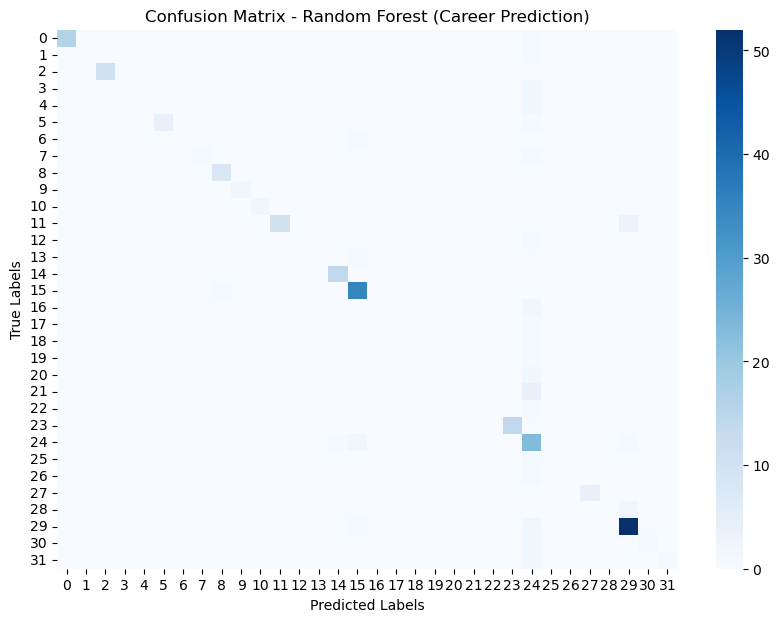

In [36]:
# Step 1️⃣2️⃣ — Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10,7))
sns.heatmap(cm, cmap='Blues', annot=False)
plt.title("Confusion Matrix - Random Forest (Career Prediction)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [37]:
# Step 1️⃣3️⃣ — Save Model and Vectorizer
joblib.dump(rf_model, "career_model_random_forest.pkl")
joblib.dump(vectorizer, "career_vectorizer.pkl")
print("\n💾 Model and Vectorizer saved successfully!")


💾 Model and Vectorizer saved successfully!


In [38]:
# Step 1️⃣4️⃣ — Predict New Career (User Input)
def predict_career_rf(course, specialization, interests, skills):
    text = f"{course} {specialization} {interests} {skills}"
    vector = vectorizer.transform([text])
    pred = rf_model.predict(vector)[0]
    
    probs = rf_model.predict_proba(vector)[0]
    classes = rf_model.classes_
    top3_idx = probs.argsort()[-3:][::-1]
    top3 = [(classes[i], round(probs[i]*100, 2)) for i in top3_idx]
    
    print(f" Predicted Career: {pred}")
    print(" Top 3 Recommendations:")
    for c, conf in top3:
        print(f"- {c} ({conf}%)")


In [39]:
predict_career_rf(
    course="bca",
    specialization="computer science",
    interests="web development, ai, data analytics",
    skills="python, html, css, javascript, sql"
)

 Predicted Career: software engineer
 Top 3 Recommendations:
- software engineer (56.67%)
- software developer (14.0%)
- data analyst (13.67%)
